In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 
import openai
from dotenv import load_dotenv, find_dotenv

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

load_dotenv(find_dotenv())
openai.api_key = os.environ["OPENAI_API_KEY"]

BASEPATH = os.environ["BASEPATH"]

In [7]:
import re
import tomllib
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from src.utils.plotting import convert_size

sns.set_context("paper")

In [3]:
def parse_directories():
    """
    Parse the directories from the configuration file.
    Returns:
    - directories: dict
    """
    with open('../config/directories.toml', 'rb') as f:
        configurations = tomllib.load(f)

    return configurations

In [ ]:
directories = parse_directories()
csv_path = os.path.join(BASEPATH, directories['public']['csv'])
article_file = os.path.join(csv_path, "neuroscience_articles_1999-2023.csv")
cluster_file = os.path.join(csv_path, "neuroscience_clusters_1999-2023.csv")

article_df = pd.read_csv(article_file)
cluster_df = pd.read_csv(cluster_file)
research_df = article_df[article_df['Type'] == 'Research']

figure_path = os.path.join(BASEPATH, directories['internal']['manuscript']['figures'], 'ABCN')
os.makedirs(figure_path, exist_ok=True)

In [35]:
# get the deciles of the citation rate for research articles per year
research_df['Decile'] = research_df.groupby('Year')['Citation Rate'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1
)



/tmp/ipykernel_16956/3410962750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_df['Decile'] = research_df.groupby('Year')['Citation Rate'].transform(


In [6]:
# Define the panel size (width, height) in centimeters
figure_size = [89, 89]

# Convert the panel size to inches
figure_size_inch = convert_size(*figure_size)

# Define the color palette
colors = ['#785ef0', '#fe6100']

# Define the font sizes
fontsize_text = 6
fontsize_ticks = 5
fontsize_legend = 5
fontsize_title = 7

### Methods over time

#### MRI

In [48]:

# General MRI pattern (broad search)
mri_pattern = r'\b(?:magnetic resonance imaging|mri|fmri)\b'

# High-precision patterns for specific MRI techniques
diffusion_mri_pattern = r'\b(?:diffusion[- ]?MRI|dMRI|diffusion tensor imaging|DTI|DTI tractography)\b'
uhf_fmri_pattern = r'\b(?:ultra[- ]?high[- ]?field[- ]?fMRI|UHF[- ]?fMRI|7T[- ]?fMRI|fMRI at 7T|fMRI at 9\.4T|fMRI at 11\.7T)\b'
layer_fmri_pattern = r'\b(?:layer[- ]?fMRI|laminar[- ]?fMRI|layer-specific fMRI|fMRI of cortical layers)\b'


# --- Patterns for a more precise 'all_articles' filter ---

# Strong keywords are unambiguously MRI-related
strong_keywords_pattern = r'\b(?:fMRI|dMRI|DTI|functional MRI|functional magnetic resonance imaging|diffusion MRI|diffusion tensor imaging|layer fMRI|laminar fMRI)\b'

# Weak keywords are ambiguous and need an MRI anchor term to be included
weak_keywords_pattern = r'\b(?:connectome|connectomics|ultra-high field|UHF|7T|7 Tesla|9.4T|9.4 Tesla|11.7T|11.7 Tesla|cortical layer|layer-specific)\b'

# Anchor terms to confirm MRI context for weak keywords
mri_anchor_pattern = r'\b(?:MRI|magnetic resonance|fMRI)\b'



In [49]:
print("Filtering articles based on defined patterns...")

# 1. General MRI articles (broad search, may include 'mention' papers)
mri_articles = research_df[research_df['Abstract'].str.contains(mri_pattern, case=False, na=False, regex=True)]

# 2. Diffusion MRI / Connectomics articles (high-precision)
diffusion_mri_articles = research_df[research_df['Abstract'].str.contains(diffusion_mri_pattern, case=False, na=False, regex=True)]

# 3. Ultra-High Field fMRI articles (high-precision)
uhf_fmri_articles = research_df[research_df['Abstract'].str.contains(uhf_fmri_pattern, case=False, na=False, regex=True)]

# 4. Layer fMRI articles (high-precision)
layer_fmri_articles = research_df[research_df['Abstract'].str.contains(layer_fmri_pattern, case=False, na=False, regex=True)]

# 5. All relevant articles (using the precise, two-part strategy)
articles_with_strong_keywords = research_df[research_df['Abstract'].str.contains(strong_keywords_pattern, case=False, na=False, regex=True)]
articles_with_weak_and_anchor = research_df[
    research_df['Abstract'].str.contains(weak_keywords_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(mri_anchor_pattern, case=False, na=False, regex=True)
]
all_articles = pd.concat([articles_with_strong_keywords, articles_with_weak_and_anchor]).drop_duplicates()


# --- Display Results ---
print(f"Found {len(mri_articles)} general MRI articles.")
print(f"Found {len(diffusion_mri_articles)} diffusion MRI / connectomics articles.")
print(f"Found {len(uhf_fmri_articles)} ultra-high field fMRI articles.")
print(f"Found {len(layer_fmri_articles)} layer fMRI articles.")
print(f"Found {len(all_articles)} articles using the precise combined filter.")

Filtering articles based on defined patterns...
Found 42669 general MRI articles.
Found 4590 diffusion MRI / connectomics articles.
Found 86 ultra-high field fMRI articles.
Found 19 layer fMRI articles.
Found 34279 articles using the precise combined filter.


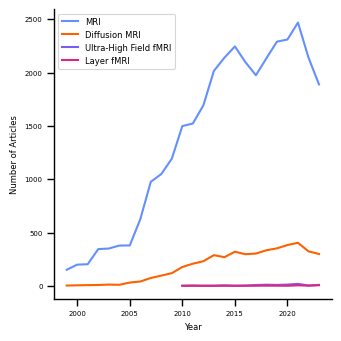

In [50]:
"""  
Only use IBM colorblind safe palettes for all visualizations.

#648fff
#785ef0
#dc267f
#fe6100
#ffb000
#000000
#ffffff

"""


plt.figure(figsize=figure_size_inch)

colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
df_list = [all_articles, diffusion_mri_articles, uhf_fmri_articles, layer_fmri_articles]
labels = ['MRI', 'Diffusion MRI', 'Ultra-High Field fMRI', 'Layer fMRI']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)

sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
#plt.ylim(0, 500)
plt.legend(title=None, fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'MRI.svg'), format='svg')
plt.show()

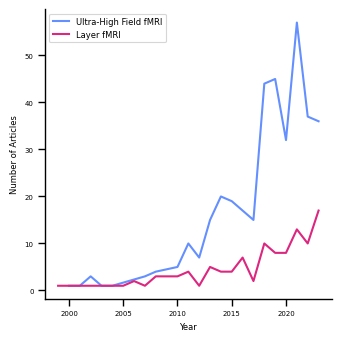

In [42]:

plt.figure(figsize=figure_size_inch)

colors = ['#648fff', '#dc267f']

df_list = [uhf_fmri_articles, layer_fmri_articles]
labels = ['Ultra-High Field fMRI', 'Layer fMRI']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)

sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
#plt.ylim(0, 500)
plt.legend(title=None, fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'uhf_MRI.svg'), format='svg')
plt.show()

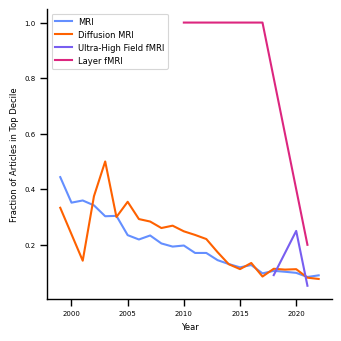

In [56]:
plt.figure(figsize=figure_size_inch)

colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']

df_list = [all_articles, diffusion_mri_articles, uhf_fmri_articles, layer_fmri_articles]
labels = ['MRI', 'Diffusion MRI', 'Ultra-High Field fMRI', 'Layer fMRI']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)

sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)
#plt.ylim(0, 500)
plt.legend(title=None, fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'MRI_hits.svg'), format='svg')
plt.show()

#### fNIRS

In [58]:
# 1. Patterns for a precise general fNIRS filter
strong_fnirs_pattern = r'\b(?:fNIRS|functional near-infrared spectroscopy)\b'
weak_fnirs_pattern = r'\b(?:NIRS|DOT|diffuse optical tomography|diffuse optical imaging)\b'  # 'DOI' was removed to avoid false positives
fnirs_anchor_pattern = r'\b(?:brain|cognitive|cortical|functional|neuro|task|prefrontal)\b'

# 2. Patterns for fNIRS subcategories
hddot_pattern = r'\b(?:high-density dot|hd-dot|high density diffuse optical tomography)\b'
hyperscan_pattern = r'\b(?:hyperscanning|multi-person nirs|two-person nirs|social nirs)\b'

In [59]:
print("Filtering articles for fNIRS and its sub-trends...")

# 1. Find all relevant fNIRS articles using the precise, two-part strategy
articles_with_strong_fnirs = research_df[research_df['Abstract'].str.contains(strong_fnirs_pattern, case=False, na=False, regex=True)]
articles_with_weak_and_anchor_fnirs = research_df[
    research_df['Abstract'].str.contains(weak_fnirs_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(fnirs_anchor_pattern, case=False, na=False, regex=True)
]
fnirs_articles = pd.concat([articles_with_strong_fnirs, articles_with_weak_and_anchor_fnirs]).drop_duplicates()

# 2. Find HD-DOT articles (must be a subset of the general fNIRS articles)
hddot_articles = fnirs_articles[fnirs_articles['Abstract'].str.contains(hddot_pattern, case=False, na=False, regex=True)]

# 3. Find fNIRS Hyperscanning articles (must be a subset of the general fNIRS articles)
hyperscan_articles = fnirs_articles[fnirs_articles['Abstract'].str.contains(hyperscan_pattern, case=False, na=False, regex=True)]


# --- Display Results ---
print(f"Found {len(fnirs_articles)} general fNIRS articles.")
print(f"Found {len(hddot_articles)} HD-DOT articles.")
print(f"Found {len(hyperscan_articles)} fNIRS hyperscanning articles.")

Filtering articles for fNIRS and its sub-trends...
Found 2490 general fNIRS articles.
Found 18 HD-DOT articles.
Found 66 fNIRS hyperscanning articles.


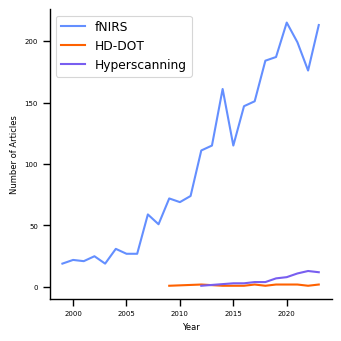

In [60]:
plt.figure(figsize=figure_size_inch)


df_list = [fnirs_articles, hddot_articles, hyperscan_articles]
labels = ['fNIRS', 'HD-DOT', 'Hyperscanning']

colors = [ '#648fff',  '#fe6100','#785ef0']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'fNIRS.svg'), format='svg')
plt.show()

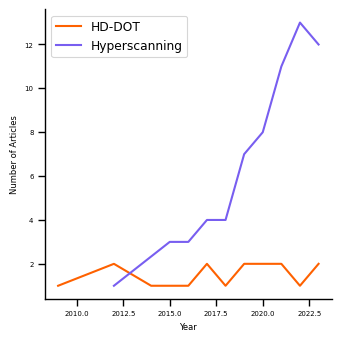

In [61]:
plt.figure(figsize=figure_size_inch)


df_list = [hddot_articles, hyperscan_articles]
labels = ['HD-DOT', 'Hyperscanning']

colors = [ '#fe6100','#785ef0']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'fNIRS_specif.svg'), format='svg')
plt.show()

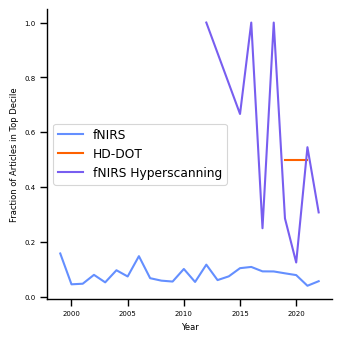

In [62]:
plt.figure(figsize=figure_size_inch)

colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
df_list = [fnirs_articles, hddot_articles, hyperscan_articles]
labels = ['fNIRS', 'HD-DOT', 'fNIRS Hyperscanning']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'fNIRS_hits.svg'), format='svg')
plt.show()

#### neurostimulation

In [63]:
# 1. TMS (Transcranial Magnetic Stimulation)
# Acronyms are highly specific in this context.
tms_pattern = r'\b(?:TMS|transcranial magnetic stimulation|rTMS|repetitive transcranial magnetic stimulation|theta burst stimulation|TBS)\b'

# 2. FUS (Focused Ultrasound)
# A single, high-precision pattern is used to avoid ambiguity with the FUS gene.
fus_pattern = r'\b(?:FUS stimulation|FUS neuromodulation|focused ultrasound stimulation|tFUS|transcranial focused ultrasound|HIFU neuromodulation|LI-FUS|LIFU|low-intensity focused ultrasound|ultrasound neuromodulation|ultrasound stimulation)\b'

# 3. tDCS (transcranial Direct Current Stimulation)
# Acronym is highly specific.
tdcs_pattern = r'\b(?:tDCS|transcranial direct current stimulation)\b'

# 4. tACS (transcranial Alternating Current Stimulation)
# Acronym is highly specific.
tacs_pattern = r'\b(?:tACS|transcranial alternating current stimulation)\b'

In [64]:
print("Filtering articles for neurostimulation trends...")

# 1. Find TMS articles
tms_articles = research_df[research_df['Abstract'].str.contains(tms_pattern, case=False, na=False, regex=True)]

# 2. Find FUS articles using the new high-precision pattern
fus_articles = research_df[research_df['Abstract'].str.contains(fus_pattern, case=False, na=False, regex=True)]

# 3. Find tDCS articles
tdcs_articles = research_df[research_df['Abstract'].str.contains(tdcs_pattern, case=False, na=False, regex=True)]

# 4. Find tACS articles
tacs_articles = research_df[research_df['Abstract'].str.contains(tacs_pattern, case=False, na=False, regex=True)]


# --- Display Results ---
print(f"Found {len(tms_articles)} TMS articles.")
print(f"Found {len(fus_articles)} FUS articles.")
print(f"Found {len(tdcs_articles)} tDCS articles.")
print(f"Found {len(tacs_articles)} tACS articles.")

Filtering articles for neurostimulation trends...
Found 5242 TMS articles.
Found 121 FUS articles.
Found 1855 tDCS articles.
Found 347 tACS articles.


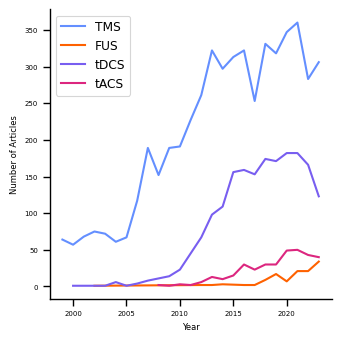

In [65]:
plt.figure(figsize=figure_size_inch)

colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
df_list = [tms_articles, fus_articles, tdcs_articles, tacs_articles]
labels = ['TMS', 'FUS', 'tDCS', 'tACS']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'neurostimulation.svg'), format='svg')
plt.show()

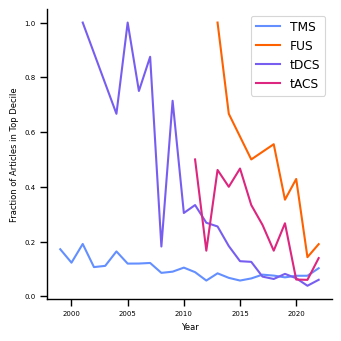

In [74]:
# hits figure

plt.figure(figsize=figure_size_inch)
df_list = [tms_articles, fus_articles, tdcs_articles, tacs_articles]
labels = ['TMS', 'FUS', 'tDCS', 'tACS']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'neurostimulation_hits.svg'), format='svg')
plt.show()

#### ephys

In [70]:
# 1. EEG (Electroencephalography)
# Terms are highly specific in this context.
eeg_pattern = r'\b(?:EEG|electroencephalography|scalp EEG|event-related potential|ERP)\b'

# 2. MEG (Magnetoencephalography)
# Acronym is highly specific.
meg_pattern = r'\b(?:MEG|magnetoencephalography)\b'

# 3. ECoG / iEEG (Electrocorticography / Intracranial EEG)
# Terms are highly specific.
ecog_pattern = r'\b(?:ECoG|electrocorticography|iEEG|intracranial EEG|subdural electrodes)\b'

# 4. Depth Recordings (SEEG)
# Terms are highly specific.
seeg_pattern = r'\b(?:SEEG|stereo-eeg|stereoelectroencephalography|depth electrodes)\b'

# 5. Microelectrode Recordings (Single/Multi-unit)
# Uses robust logic to handle the ambiguous 'MEA' acronym.
strong_micro_pattern = r'\b(?:single-unit|multi-unit|single-neuron|multi-neuron|microelectrode array|Utah array)\b'
weak_micro_pattern = r'\b(?:MEA)\b'
micro_anchor_pattern = r'\b(?:recording|electrode|neuron|array|activity)\b'

In [71]:
print("Filtering articles for electrophysiology trends...")

# 1. Find EEG articles
eeg_articles = research_df[research_df['Abstract'].str.contains(eeg_pattern, case=False, na=False, regex=True)]

# 2. Find MEG articles
meg_articles = research_df[research_df['Abstract'].str.contains(meg_pattern, case=False, na=False, regex=True)]

# 3. Find ECoG / iEEG articles
ecog_articles = research_df[research_df['Abstract'].str.contains(ecog_pattern, case=False, na=False, regex=True)]

# 4. Find Depth Recording (SEEG) articles
seeg_articles = research_df[research_df['Abstract'].str.contains(seeg_pattern, case=False, na=False, regex=True)]

# 5. Find Microelectrode Recording articles
articles_with_strong_micro = research_df[research_df['Abstract'].str.contains(strong_micro_pattern, case=False, na=False, regex=True)]
articles_with_weak_and_anchor_micro = research_df[
    research_df['Abstract'].str.contains(weak_micro_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(micro_anchor_pattern, case=False, na=False, regex=True)
]
microelectrode_articles = pd.concat([articles_with_strong_micro, articles_with_weak_and_anchor_micro]).drop_duplicates()


# --- Display Results ---
print(f"Found {len(eeg_articles)} EEG articles.")
print(f"Found {len(meg_articles)} MEG articles.")
print(f"Found {len(ecog_articles)} ECoG / iEEG articles.")
print(f"Found {len(seeg_articles)} SEEG / depth recording articles.")
print(f"Found {len(microelectrode_articles)} microelectrode recording articles.")

Filtering articles for electrophysiology trends...
Found 19418 EEG articles.
Found 3807 MEG articles.
Found 1112 ECoG / iEEG articles.
Found 318 SEEG / depth recording articles.
Found 2481 microelectrode recording articles.


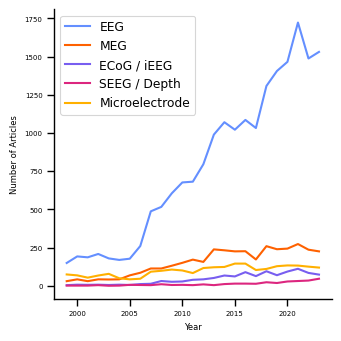

In [75]:
plt.figure(figsize=figure_size_inch)

colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f', '#ffb000']
df_list = [eeg_articles, meg_articles, ecog_articles, seeg_articles, microelectrode_articles]
labels = ['EEG', 'MEG', 'ECoG / iEEG', 'SEEG / Depth', 'Microelectrode']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'electrophysiology.svg'), format='svg')
plt.show()

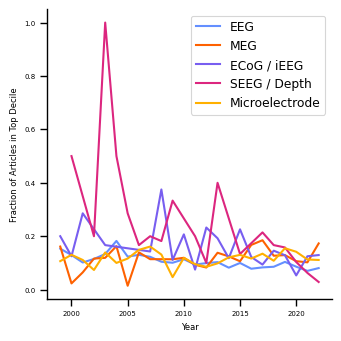

In [76]:
# hits plot
plt.figure(figsize=figure_size_inch)
df_list = [eeg_articles, meg_articles, ecog_articles, seeg_articles, microelectrode_articles]
labels = ['EEG', 'MEG', 'ECoG / iEEG', 'SEEG / Depth', 'Microelectrode']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f', '#ffb000']
for df , label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'electrophysiology_hits.svg'), format='svg')
plt.show()

#### Comp neuro

In [78]:
# Pillar 1: Biophysical & Theoretical Modeling
biophys_model_pattern = r'\b(?:computational model|biophysical model|spiking neuron|integrate-and-fire|Hodgkin-Huxley|mean-field model|neural field|dynamic causal modeling|DCM)\b'

# Pillar 2: DNNs as Brain Models
dnn_term_pattern = r'\b(?:deep neural network|DNN|convolutional neural network|CNN|recurrent neural network|RNN|transformer network)\b'
brain_model_anchor_pattern = r'\b(?:model of V1|model of the cortex|as a model|brain model|neural representation|encoding model|representational similarity|brain-inspired)\b'

# Pillar 3: Advanced ML-Based Data Analysis
ml_analysis_pattern = r'\b(?:decoding|multivariate pattern analysis|MVPA|representational similarity analysis|RSA|encoding model)\b'

# --- Define Exclusion Pattern ---
# This pattern targets papers using DNNs as a 'tool' for a task, not as a 'model' of the brain.
exclusion_pattern = r'\b(?:automated detection|computer-aided diagnosis|image segmentation|classification accuracy|detecting abnormalities|achieved an accuracy of)\b'


In [79]:
print("Filtering articles for computational neuroscience trends...")

# 1. Find articles from Pillar 1
biophys_model_articles = research_df[research_df['Abstract'].str.contains(biophys_model_pattern, case=False, na=False, regex=True)]

# 2. Find articles from Pillar 2
dnn_as_model_articles = research_df[
    research_df['Abstract'].str.contains(dnn_term_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(brain_model_anchor_pattern, case=False, na=False, regex=True)
]

# 3. Find articles from Pillar 3
ml_analysis_articles = research_df[research_df['Abstract'].str.contains(ml_analysis_pattern, case=False, na=False, regex=True)]


# --- Combine, Deduplicate, and Exclude --- 

# First, combine all included articles from the three pillars
initial_articles = pd.concat([
    biophys_model_articles,
    dnn_as_model_articles,
    ml_analysis_articles
]).drop_duplicates()

# Second, apply the exclusion filter as a final cleaning step
comp_neuro_articles = initial_articles[
    ~initial_articles['Abstract'].str.contains(exclusion_pattern, case=False, na=False, regex=True)
]


# --- Display Results ---

print(f"Found {len(initial_articles)} candidate articles before exclusion.")
print(f"Found {len(comp_neuro_articles)} computational neuroscience articles after final exclusion.")
print("--- Pillar Contributions (before exclusion) ---")
print(f"  - {len(biophys_model_articles)} from Biophysical/Theoretical Modeling")
print(f"  - {len(dnn_as_model_articles)} from DNNs as Brain Models")
print(f"  - {len(ml_analysis_articles)} from Advanced ML Analysis")


# apply the exclusion filter as a final cleaning step
biophys_model_articles = biophys_model_articles[
    ~biophys_model_articles['Abstract'].str.contains(exclusion_pattern, case=False, na=False, regex=True)
]
dnn_as_model_articles = dnn_as_model_articles[
    ~dnn_as_model_articles['Abstract'].str.contains(exclusion_pattern, case=False, na=False, regex=True)
]

print(f"After exclusion filter:")
print(f"  - {len(biophys_model_articles)} Biophysical/Theoretical Modeling articles remain.")
print(f"  - {len(dnn_as_model_articles)} DNNs as Brain Models articles remain.")

Filtering articles for computational neuroscience trends...
Found 6440 candidate articles before exclusion.
Found 6329 computational neuroscience articles after final exclusion.
--- Pillar Contributions (before exclusion) ---
  - 3255 from Biophysical/Theoretical Modeling
  - 38 from DNNs as Brain Models
  - 3216 from Advanced ML Analysis
After exclusion filter:
  - 3247 Biophysical/Theoretical Modeling articles remain.
  - 38 DNNs as Brain Models articles remain.


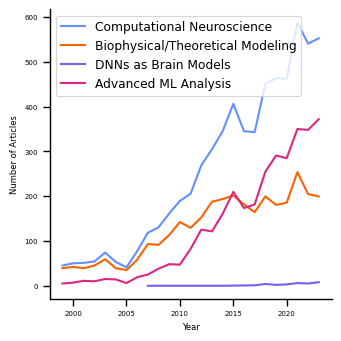

In [80]:
plt.figure(figsize=figure_size_inch)
df_list = [comp_neuro_articles, biophys_model_articles, dnn_as_model_articles, ml_analysis_articles]
labels = ['Computational Neuroscience', 'Biophysical/Theoretical Modeling', 'DNNs as Brain Models', 'Advanced ML Analysis']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'computational_neuroscience.svg'), format='svg')
plt.show()  

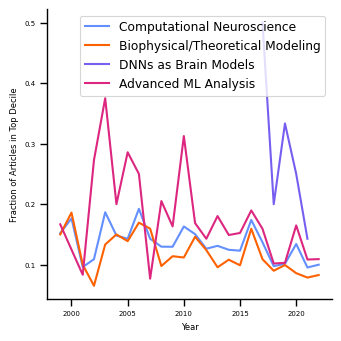

In [81]:
# hits plot
plt.figure(figsize=figure_size_inch)
df_list = [comp_neuro_articles, biophys_model_articles, dnn_as_model_articles, ml_analysis_articles]
labels = ['Computational Neuroscience', 'Biophysical/Theoretical Modeling', 'DNNs as Brain Models', 'Advanced ML Analysis']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'computational_neuroscience_hits.svg'), format='svg')
plt.show()

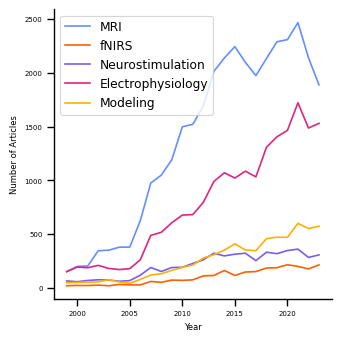

In [87]:
# CN methods counts

neurostim_articles = pd.concat([tms_articles, fus_articles, tdcs_articles, tacs_articles]).drop_duplicates()
ephys_articles = pd.concat([eeg_articles, meg_articles, ecog_articles, seeg_articles, microelectrode_articles]).drop_duplicates()
comp_neuro_articles = pd.concat([biophys_model_articles, dnn_as_model_articles, ml_analysis_articles]).drop_duplicates()

plt.figure(figsize=figure_size_inch)
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f', '#ffb000']
df_list = [all_articles, fnirs_articles, tms_articles, eeg_articles, comp_neuro_articles]
labels = ['MRI', 'fNIRS', 'Neurostimulation', 'Electrophysiology', 'Modeling']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color)

sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'cn_methods_counts.svg'), format='svg')
plt.show()

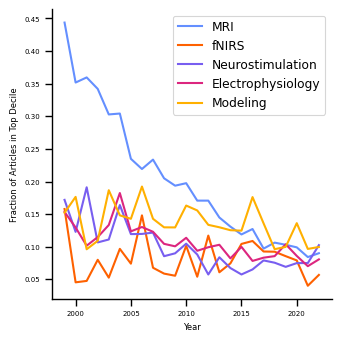

In [88]:
# hits plot
plt.figure(figsize=figure_size_inch)
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f', '#ffb000']
df_list = [all_articles, fnirs_articles, tms_articles, eeg_articles, comp_neuro_articles]
labels = ['MRI', 'fNIRS', 'Neurostimulation', 'Electrophysiology', 'Modeling']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'cn_methods_hits.svg'), format='svg')
plt.show()

## Theory

In [ ]:
# 1. Predictive Coding / Processing (Refined)
strong_pc_pattern = r'\b(?:predictive coding|predictive processing)\b'
component_pc_pattern = r'\b(?:prediction error|sensory prediction|error signal|error neuron)\b' # 'generative model' moved to anchored search
prediction_pattern = r'\bprediction\b'
pc_anchor_pattern = r'\b(?:top-down|sensory|cortical|neural)\b'
gm_pattern = r'\bgenerative model\b'
gm_anchor_pattern = r'\b(?:brain|neural|cortical)\b'

# 2. The Bayesian Brain (Refined)
strong_bayesian_pattern = r'\b(?:Bayesian brain)\b'
weak_bayesian_pattern = r'\b(?:Bayesian model|Bayesian inference|probabilistic model|belief updating|prior distribution|posterior probability)\b'
bayesian_anchor_pattern = r'\b(?:brain|neural|neuron|cortical)\b'
exclusion_bayesian_pattern = r'\b(?:Bayesian statistics|Bayesian analysis|Bayesian statistical)\b'

# 3. The Critical Brain Hypothesis (Unchanged, already robust)
strong_criticality_pattern = r'\b(?:critical brain|self-organized criticality|neuronal avalanches)\b'
weak_criticality_pattern = r'\b(?:criticality|power-law|scale-free)\b'
criticality_anchor_pattern = r'\b(?:neural|neuronal|brain|cortical|activity|dynamics)\b'

# 4. Communication Through Coherence (CTC) (Refined)
strong_ctc_pattern = r'\b(?:communication through coherence)\b' # 'CTC' acronym moved to weak pattern
weak_ctc_pattern = r'\b(?:CTC|coherence|synchrony|synchronization|phase-locking)\b'
ctc_anchor_pattern = r'\b(?:communication|neural|neuronal|oscillatory|binding|routing)\b'

In [90]:
print("Filtering articles for theory trends with refined logic...")

# 1. Find Predictive Coding articles
pc_strong_articles = research_df[research_df['Abstract'].str.contains(strong_pc_pattern, case=False, na=False, regex=True)]
pc_component_articles = research_df[research_df['Abstract'].str.contains(component_pc_pattern, case=False, na=False, regex=True)]
pc_anchored_articles = research_df[
    research_df['Abstract'].str.contains(prediction_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(pc_anchor_pattern, case=False, na=False, regex=True)
]
pc_gm_anchored_articles = research_df[
    research_df['Abstract'].str.contains(gm_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(gm_anchor_pattern, case=False, na=False, regex=True)
]
predictive_coding_articles = pd.concat([pc_strong_articles, pc_component_articles, pc_anchored_articles, pc_gm_anchored_articles]).drop_duplicates()

# 2. Find Bayesian Brain articles
bayesian_strong_articles = research_df[research_df['Abstract'].str.contains(strong_bayesian_pattern, case=False, na=False, regex=True)]
bayesian_anchored_articles = research_df[
    research_df['Abstract'].str.contains(weak_bayesian_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(bayesian_anchor_pattern, case=False, na=False, regex=True)
]
bayesian_brain_candidates = pd.concat([bayesian_strong_articles, bayesian_anchored_articles]).drop_duplicates()
bayesian_brain_articles = bayesian_brain_candidates[
    ~bayesian_brain_candidates['Abstract'].str.contains(exclusion_bayesian_pattern, case=False, na=False, regex=True)
]

# 3. Find Critical Brain articles
criticality_strong_articles = research_df[research_df['Abstract'].str.contains(strong_criticality_pattern, case=False, na=False, regex=True)]
criticality_anchored_articles = research_df[
    research_df['Abstract'].str.contains(weak_criticality_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(criticality_anchor_pattern, case=False, na=False, regex=True)
]
criticality_articles = pd.concat([criticality_strong_articles, criticality_anchored_articles]).drop_duplicates()

# 4. Find Communication Through Coherence articles
ctc_strong_articles = research_df[research_df['Abstract'].str.contains(strong_ctc_pattern, case=False, na=False, regex=True)]
ctc_anchored_articles = research_df[
    research_df['Abstract'].str.contains(weak_ctc_pattern, case=False, na=False, regex=True) &
    research_df['Abstract'].str.contains(ctc_anchor_pattern, case=False, na=False, regex=True)
]
ctc_articles = pd.concat([ctc_strong_articles, ctc_anchored_articles]).drop_duplicates()


# --- Display Results ---
print(f"Found {len(predictive_coding_articles)} Predictive Coding articles.")
print(f"Found {len(bayesian_brain_articles)} Bayesian Brain articles.")
print(f"Found {len(criticality_articles)} Critical Brain articles.")
print(f"Found {len(ctc_articles)} Communication Through Coherence articles.")

Filtering articles for theory trends with refined logic...
Found 3721 Predictive Coding articles.
Found 529 Bayesian Brain articles.
Found 542 Critical Brain articles.
Found 4728 Communication Through Coherence articles.


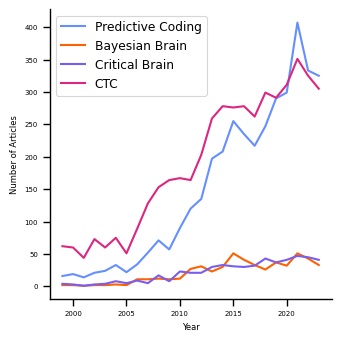

In [92]:
plt.figure(figsize=figure_size_inch)
df_list = [predictive_coding_articles, bayesian_brain_articles, criticality_articles, ctc_articles]
labels = ['Predictive Coding', 'Bayesian Brain', 'Critical Brain', 'CTC']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
for df, label, color in zip(df_list, labels, colors):
    yearly_counts = df['Year'].value_counts().sort_index()
    sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Number of Articles', fontsize=fontsize_text)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'theories_refined.svg'), format='svg')
plt.show()

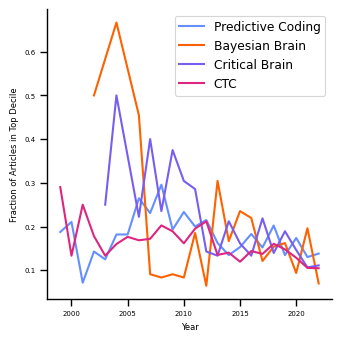

In [94]:
# hits plot
plt.figure(figsize=figure_size_inch)
df_list = [predictive_coding_articles, bayesian_brain_articles, criticality_articles, ctc_articles]
labels = ['Predictive Coding', 'Bayesian Brain', 'Critical Brain', 'CTC']
colors = [ '#648fff',  '#fe6100','#785ef0', '#dc267f']
for df, label, color in zip(df_list, labels, colors):
    
    # compute the fraction of articles in the top decile per year
    top_decile_fraction = df[df['Decile'] == 10].groupby('Year').size() / df.groupby('Year').size()

    sns.lineplot(x=top_decile_fraction.index, y=top_decile_fraction.values, label=label, color=color, linewidth=1.5)
sns.despine()
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel('Year', fontsize=fontsize_text)
plt.ylabel('Fraction of Articles in Top Decile', fontsize=fontsize_text)    
plt.tight_layout()
plt.savefig(os.path.join(figure_path, 'theories_refined_hits.svg'), format='svg')
plt.show()

In [118]:
most_cited_2023 = research_df[research_df['Year'] >= 2023].sort_values(by='Citations', ascending=False).head(100)
print("Top 100 most cited articles from 2023:")
for index, row in most_cited_2023.iterrows():
    print(f"- {row['Title']} (Citations: {row['Citations']})")

Top 100 most cited articles from 2023:
- Fast and sensitive GCaMP calcium indicators for imaging neural populations. (Citations: 329.0)
- cGAS-STING drives ageing-related inflammation and neurodegeneration. (Citations: 291.0)
- A high-resolution transcriptomic and spatial atlas of cell types in the whole mouse brain. (Citations: 268.0)
- Microglia-mediated T cell infiltration drives neurodegeneration in tauopathy. (Citations: 262.0)
- A somato-cognitive action network alternates with effector regions in motor cortex. (Citations: 219.0)
- Transcriptomic diversity of cell types across the adult human brain. (Citations: 209.0)
- Walking naturally after spinal cord injury using a brain-spine interface. (Citations: 206.0)
- The connectome of an insect brain. (Citations: 199.0)
- Psychedelics promote neuroplasticity through the activation of intracellular 5-HT2A receptors. (Citations: 192.0)
- Microglia regulate central nervous system myelin growth and integrity. (Citations: 188.0)
- Psyched

In [123]:
journal_replacements = dict()
unique_journals = research_df["Journal"].unique()
for journal in unique_journals:
    if ' : ' in journal:
        journal_replacements[journal] = journal.split(' : ')[0]
    elif '(' in journal:
        journal_replacements[journal] = journal.split(' (')[0]

journal_replacements['Proceedings of the National Academy of Sciences of the United States of America'] = 'PNAS'
journal_replacements['Proceedings of the Japan Academy. Series B, Physical and biological sciences'] = 'PJA Series B'
journal_replacements['Nature neuroscience'] = 'Nature Neuroscience'
journal_replacements['Nature human behaviour'] = 'Nature Human Behaviour'

# Replace journal names using the dictionary
research_df["Journal"] = research_df["Journal"].replace(journal_replacements)

/tmp/ipykernel_16956/888440783.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  research_df["Journal"] = research_df["Journal"].replace(journal_replacements)


In [131]:
journals_of_interest = ['Nature', 'Nature Neuroscience', 'Nature Human Behaviour', 'Science', 'PNAS', 'Neuron', 'The Lancet Neurology', 'Brain', 'eLife', 'Cerebral Cortex']

not_cited_2023 = research_df[(research_df['Year'] == 2023) & (research_df['Citations'] == 0)]


print("Selection of 200 articles from 2023 with zero citations in high impact journals:")
# limite only to articles published in Nature journals
not_cited_2023 = not_cited_2023[not_cited_2023['Journal'].isin(journals_of_interest)]
print(f"Number of articles from 2023 with zero citations: {len(not_cited_2023)}")
for index, row in not_cited_2023.head(200).iterrows():
    print(f"- {row['Title']}")

Selection of 200 articles from 2023 with zero citations in high impact journals:
Number of articles from 2023 with zero citations: 40
- Signal denoising through topographic modularity of neural circuits.
- Forming new connections: Advances in human stem-cell-derived interneuron therapy for treating epilepsy.
- The temporal and contextual stability of activity levels in hippocampal CA1 cells.
- Brain structure and function link to variation in biobehavioral dimensions across the psychopathological continuum.
- Male rodent perirhinal cortex, but not ventral hippocampus, inhibition induces approach bias under object-based approach-avoidance conflict.
- GABAergic miR-34a regulates Dorsal Raphè inhibitory transmission in response to aversive, but not rewarding, stimuli.
- Adult-born granule cells improve stimulus encoding and discrimination in the dentate gyrus.
- Locus of control: How the brain gives up when failure is taken for granted.
- The differentiation and integration of the hippoca